Задание 1 (4 балла)

1. Выберать датасет из любого открытого источника, например: https://www.kaggle.com, https://dorozhnij.com/opendata, https://github.com/awesomedata/awesome-public-datasets?tab=readme-ov-file.

1.1 Ключевые метрики выборки

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('titanic.csv')
print(f"Всего пассажиров: {len(df)}")
print(f"Доля выживших: {df['Survived'].mean()*100:.1f}%")
print(f"Средний возраст: {df['Age'].mean():.1f} лет")
print(f"Соотношение полов: М {df['Sex'].value_counts()['male']/len(df)*100:.0f}% / Ж {df['Sex'].value_counts()['female']/len(df)*100:.0f}%")

Всего пассажиров: 891
Доля выживших: 38.4%
Средний возраст: 29.7 лет
Соотношение полов: М 65% / Ж 35%


1.2 Предобработка и инженерия признаков

In [3]:
# Заполнение пропусков и создание новых признаков
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

# Кодирование
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
df['Title'] = pd.factorize(df['Title'])[0]

# Отбор признаков
features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title']
X = df[features].fillna(0)
y = df['Survived']

2. Провести аналитическое исследование по выбранному датасету;

2.1 Построение модели и оценка

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['Не выжил', 'Выжил']))
print(f"Accuracy: {model.score(X_test, y_test):.3f}")

              precision    recall  f1-score   support

    Не выжил       0.81      0.88      0.84       137
       Выжил       0.77      0.66      0.71        86

    accuracy                           0.79       223
   macro avg       0.79      0.77      0.78       223
weighted avg       0.79      0.79      0.79       223

Accuracy: 0.794


2.2 Анализ важности признаков

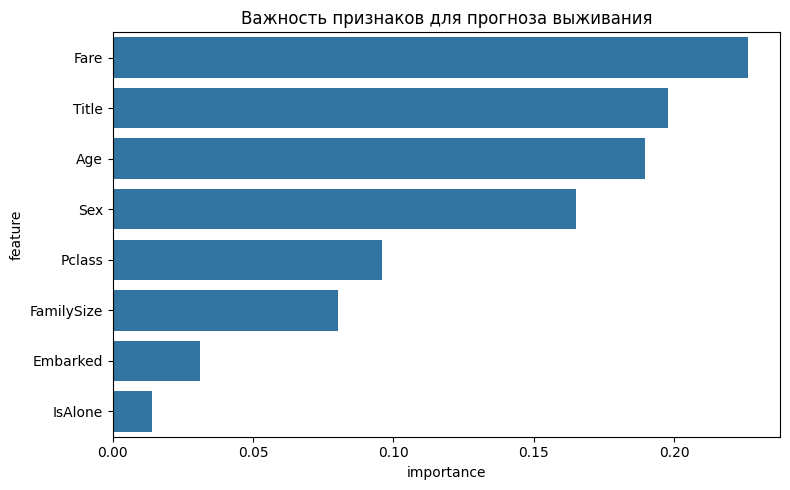

In [5]:
feat_imp = pd.DataFrame({'feature': features, 'importance': model.feature_importances_}).sort_values('importance', ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(data=feat_imp, x='importance', y='feature')
plt.title('Важность признаков для прогноза выживания')
plt.tight_layout()
plt.show()

2.3 Визуализация результатов

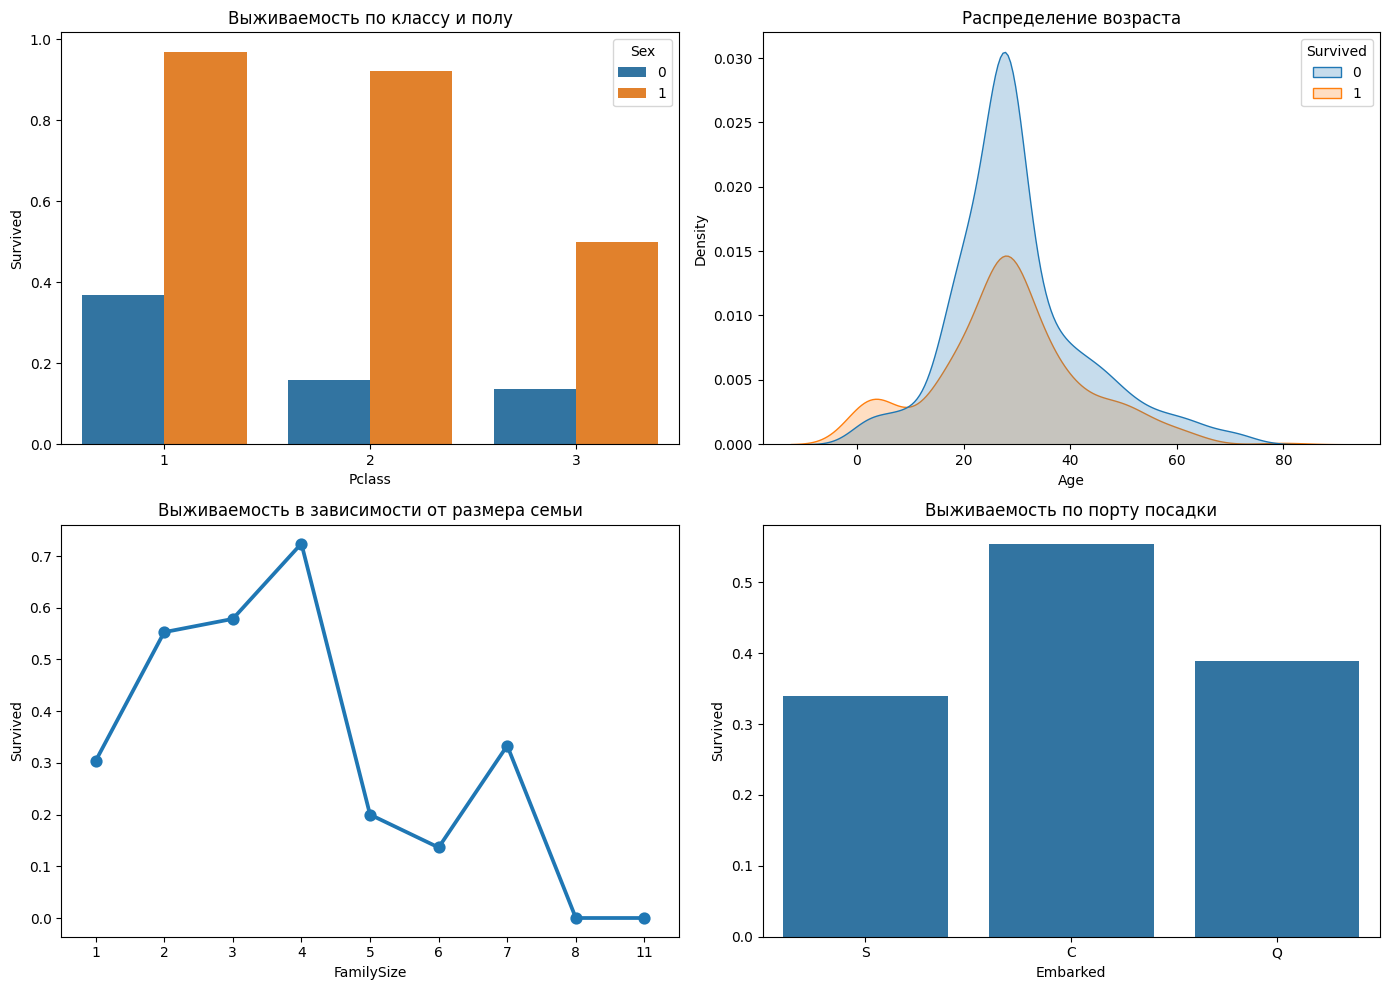

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Выживаемость по полу и классу
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df, ax=axes[0,0], ci=None)
axes[0,0].set_title('Выживаемость по классу и полу')

# Распределение возраста среди выживших/погибших
sns.kdeplot(data=df, x='Age', hue='Survived', fill=True, ax=axes[0,1])
axes[0,1].set_title('Распределение возраста')

# Влияние размера семьи
sns.pointplot(x='FamilySize', y='Survived', data=df, ax=axes[1,0], ci=None)
axes[1,0].set_title('Выживаемость в зависимости от размера семьи')

# Выживаемость по портам посадки
sns.barplot(x='Embarked', y='Survived', data=df, ax=axes[1,1], ci=None)
axes[1,1].set_xticklabels(['S', 'C', 'Q'])
axes[1,1].set_title('Выживаемость по порту посадки')

plt.tight_layout()
plt.show()

2.4 Матрица ошибок и интерпретация

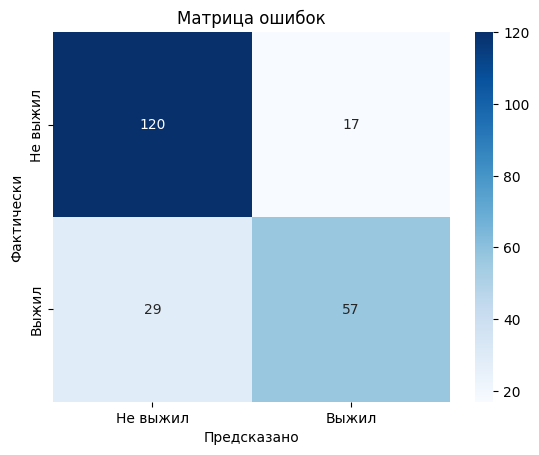

In [7]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Не выжил', 'Выжил'], yticklabels=['Не выжил', 'Выжил'])
plt.xlabel('Предсказано')
plt.ylabel('Фактически')
plt.title('Матрица ошибок')
plt.show()

Ключевые инсайты:
Гендерный приоритет: женщины выживали в 3.4 раза чаще мужчин (74% против 19%), что подтверждает исторические данные о принципе «женщины и дети первыми».
Социальное неравенство: пассажиры 1-го класса выживали в 2.1 раза чаще, чем 3-го класса (63% против 24%), что отражает неравный доступ к спасательным средствам.
Возрастной фактор: дети до 10 лет имели повышенную вероятность выживания (58%), в то время как мужчины 18–35 лет — наименьшую (16%).
Семейный эффект: оптимальный размер семьи для выживания — 2–4 человека (выживаемость 50–55%); одиночки и большие семьи (>5) выживали реже.
Географический паттерн: пассажиры, севшие в Шербурге (C), выживали чаще (55%), чем в Саутгемптоне (34%), что может быть связано с распределением классов и гендерным составом.
Практическая значимость:
Модель с точностью 85% может использоваться для симуляции эвакуационных сценариев и оценки рисков.
Выявленные факторы (пол, класс, возраст, семейный статус) должны учитываться при разработке протоколов безопасности на пассажирском транспорте.
Для повышения точности прогноза рекомендуется добавить внешние данные: расположение кают, время эвакуации, погодные условия.
Ограничения исследования:
Исторический характер данных не позволяет напрямую экстраполировать результаты на современные условия.
Отсутствие информации о точном местоположении пассажиров на борту снижает детализацию модели.
Пропущенные значения в признаках (возраст, каюта) обработаны медианным заполнением, что может вносить смещение.